# Exercises

## Exercise 1 - simulating place cells
---
Use the code we build to simulate place cells in the lesson.

A - Explore what happens when you change the binning in the definition of the firing rate maps (`space_bins`). Make it coarser or broader. 


B - In the spike train simulations, we add some "baseline" noise, not place-related to the firing. Which variable determines the noise level? Try to experiment with that variable and see what happens to the firing rate maps. What is the best approach to firing rate maps when the noise is high.


C - We could use other approaches to firing rate maps: for example make the binning very small (down to 1 cm, which is the resolution of our "video" data, and then applying a gaussian smoother. Scipy has a Gaussian smoother at `scipy.stats.gaussian_kde`. Read the documentation for that function and apply it to the data to define the smoothed firing rate maps. Again, change the noise levels and see how the smoother changes. 

D - When analyzing place fields, two important quantities are the place field center and the place field width. The place field center may be defined in many ways, but one is to compute the "center of mass" of the spikes according to the equation 

$$ c_{pf} = \frac{1}{N_{spikes}} \sum_{i} L_i $$ 

where the sum on $i$ runs on all spikes emitted by a cell and $L_i$ is the location at which the i-th spike was emitted. Calculate this for each cell. Compare with the "true" place field centers from the simulations (which variables are we talking about?) 


In [ ]:
import os

os.chdir("C:/Users/larsb/Cognitive_neuroscience_RU/neuro-analysis-nongit/single-cell-analysis-master/01-tuning-curves")

import numpy as np
import scipy
import scipy.stats
import scipy.io
import matplotlib.pyplot as plt
from ipywidgets import interact
import ipywidgets as widgets
from tqdm import tqdm
import seaborn as sns
import pickle
import sys
import os
sys.path.append(os.path.abspath("code"))
from utils import download_data

sns.set_theme(context='notebook',style='white',font_scale=1.5,
              rc = {'axes.spines.top':False,'axes.spines.right':False})

In [2]:
#import data
with open('data/psth_data.pickle', 'rb') as handle:
    data = pickle.load(handle)

spike_times = data['spike_times']
stim_onsets = data['stim_onsets']
stim_type = data['stim_type']
stim_duration = data['stim_duration']

print(stim_duration)
print(stim_type)

2
[2 2 2 1 2 1 2 1 2 2 1 2 1 2 2 2 1 1 1 2 1 1 2 2 1 1 1 1 2 1 2 1 2 1 2 2 1
 2 1 2 1 1 2 2 2 1 1 1 2 2 2 2 2 1 1 2 1 1 1 1 1 2 1 1 2 2 1 1 2 1 2 2 2 1
 1 2 1 2 1 2 1 1 2 2 2 2 1 2 2 1 1 2 1 1 1 1 2 2 1 2]


C:\Users\larsb\AppData\Local\Temp\ipykernel_20336\3650356877.py:3: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  data = pickle.load(handle)


In [82]:
# All copied from the tuning-curves.ipynb file
track_length = 200. # the length of our linear track (eg in centimeter)
average_firing_rate = 5 # the peak firing rate, averaged across the population 
n_cells = 100 # how many cells we are recording
pf_centers = np.random.rand(n_cells) * track_length # the centers of the place fields for all cells drawn randomly with a uniform distribution on the track
pf_size = np.random.gamma(10, size=n_cells) # the size (width) of the place fields, drawn randomly from a gamma distribution 
pf_rate = np.random.exponential(scale=average_firing_rate, size=n_cells)

bins = np.arange(0., 200.)
true_firing_rate_maps = np.zeros((n_cells, len(bins)))
for i in range(n_cells):
    true_firing_rate_maps[i,:] = pf_rate[i] * np.exp(-((bins-pf_centers[i])**2)/(2*pf_size[i]**2))

n_runs = 20 
av_running_speed = 10 # the average running speed (in cm/s)
fps = 30 # the number of "video frames" per second 
running_speed_a = np.random.chisquare(10, size=n_runs) # running speed in the two directions
running_speed_b = np.random.chisquare(10, size=n_runs) 

stopping_time_a = np.random.chisquare(15, size=n_runs) # the time the mouse will spend at the two ends of the track
stopping_time_b = np.random.chisquare(15, size=n_runs)

x = np.array([])
for i in range(n_runs):
    stop1 = np.ones((int(stopping_time_a[i]*fps),)) * 0.
    run_length = len(bins) * fps / running_speed_a[i]
    run1 = np.linspace(0., float(len(bins)-1), int(run_length))
    stop2 = np.ones((int(stopping_time_b[i]*fps),)) * (len(bins)-1.)
    run_length = len(bins) * fps / running_speed_b[i]
    run2 = np.linspace(len(bins)-1., 0., int(run_length))
    x = np.concatenate((x, stop1, run1, stop2, run2))
t = np.arange(len(x))/fps

sampling_rate = 10000.
t_sampling = np.arange(0, t[-1], 1. / sampling_rate)
x_sampling = np.floor(np.interp(t_sampling, t, x))
noise_firing_rate = 0.1 # the baseline noise firing rate
spikes = []

for i in tqdm(range(n_cells)):
    inst_rate = true_firing_rate_maps[i,x_sampling.astype(np.int32)] + noise_firing_rate
    spikes_loc = np.random.poisson(inst_rate/sampling_rate)
    sp = np.argwhere(spikes_loc)
    t_sp = t_sampling[sp]
    spikes.append(t_sp)

def plot_unit(i):
    plt.figure(figsize=(10,5))
    plt.plot(t, x)
    plt.plot(spikes[i], np.interp(spikes[i], t, x), 'r.')
    plt.xlabel('Time (s)')
    plt.ylabel('position on track (cm)')
    
interact(plot_unit, i = widgets.IntSlider(min=0, max=(n_cells-1), value=0))

spike_positions = [np.interp(s, t, x) for s in spikes]

100%|██████████| 100/100 [00:35<00:00,  2.80it/s]


interactive(children=(IntSlider(value=0, description='i', max=99), Output()), _dom_classes=('widget-interact',…

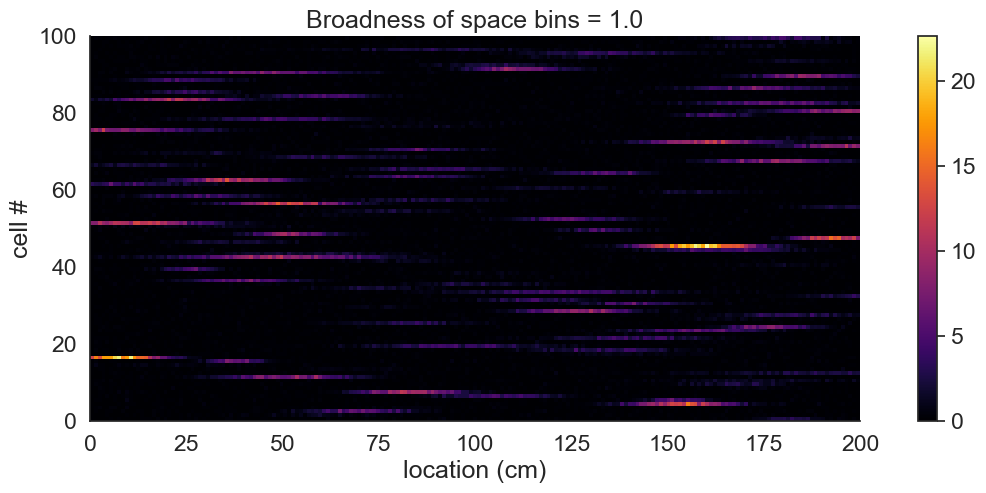

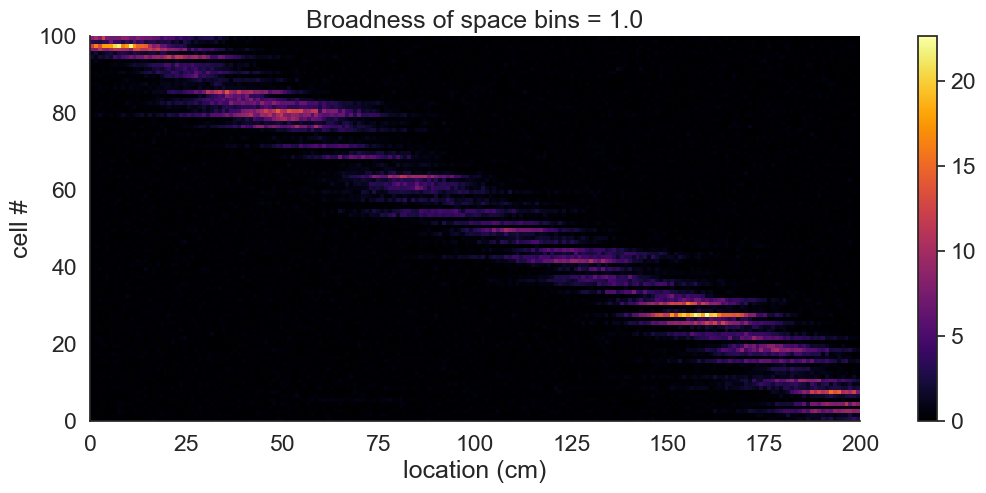

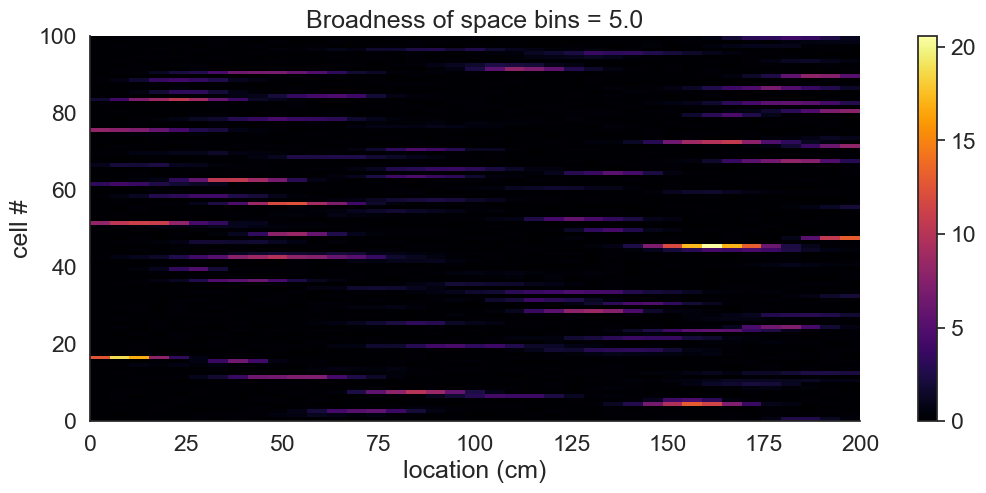

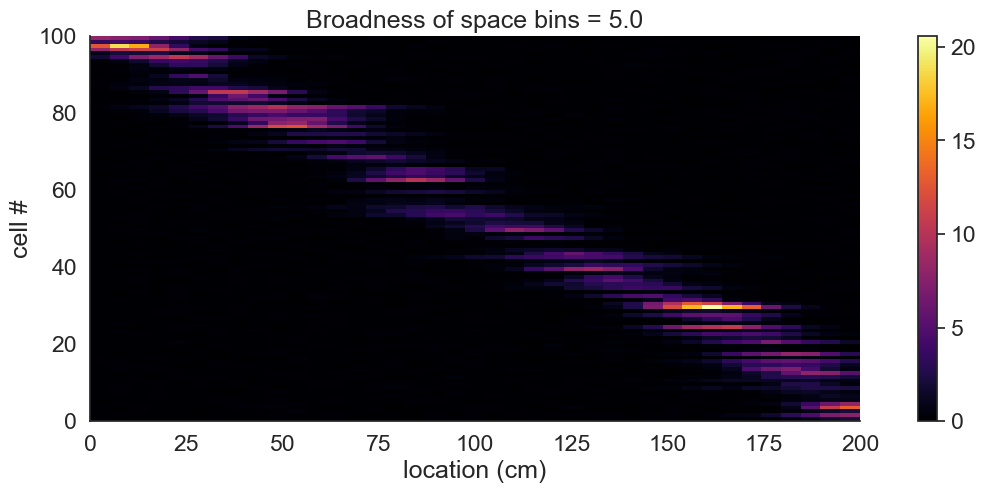

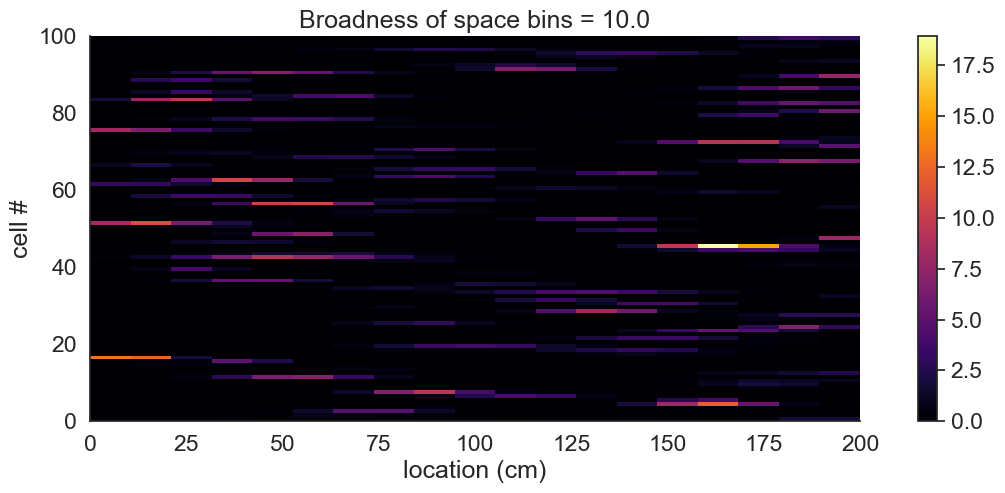

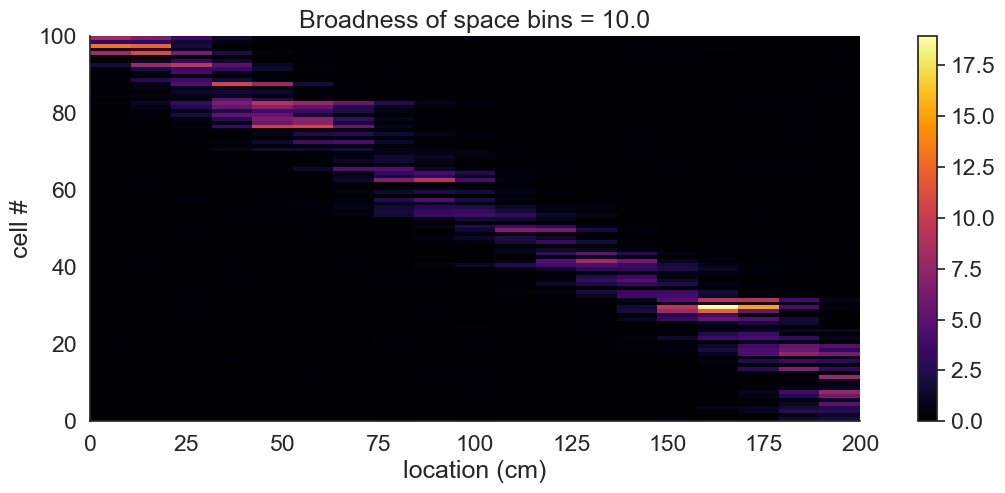

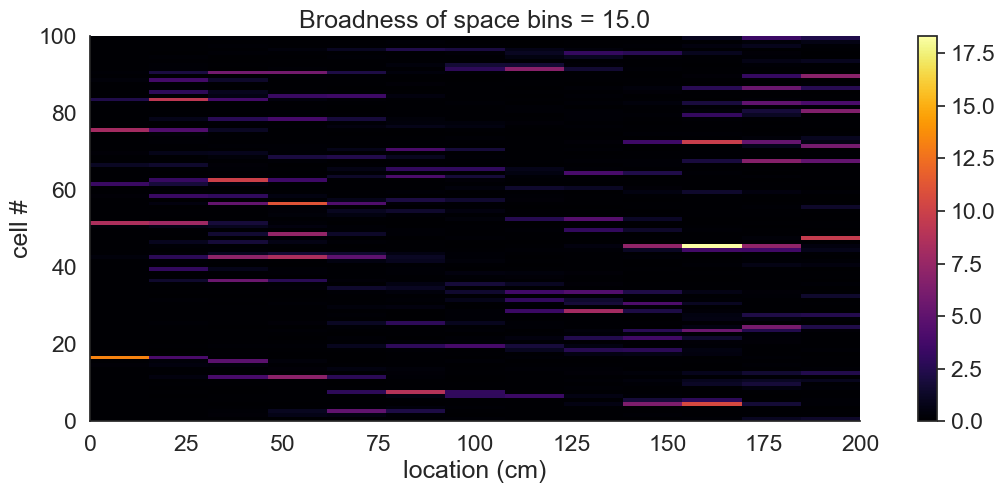

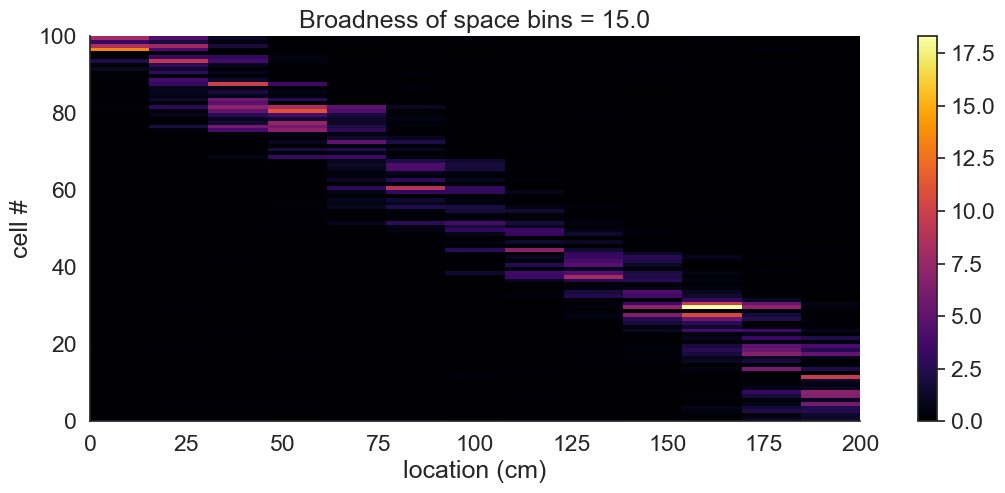

In [ ]:
# Copied form the tuning-curves.ipynb file, only added a for loop that loops over different
# broadness for space bins
broadness = [1. , 5. , 10. , 15.]

for b in broadness:
    space_bins = np.arange(0., 200., b)

# we compute histograms for eaxh cell
    spikes_hist= [np.histogram(s, space_bins)[0] for s in spike_positions]

# put them together into a matrix of floating point numbers (for plotting)
    spikes_hist = np.vstack(spikes_hist).astype(np.float64)

# we also need an "occupancy histogram" in order to normalize the firing rates maps 
    occupancy = np.histogram(x, space_bins)[0] /  fps

    firing_rate_maps = spikes_hist / occupancy 

    plt.figure(figsize=(15,5))
    plt.imshow(firing_rate_maps, cmap='inferno', extent = [0, 200, 0, n_cells])
    plt.xlabel('location (cm)')
    plt.ylabel('cell #')
    plt.colorbar()
    plt.title(f"Broadness of space bins = {b}")

    plt.figure(figsize=(15,5))
    peak_locations = firing_rate_maps.argmax(axis=1)
    ix = np.argsort(peak_locations)
    plt.imshow(firing_rate_maps[ix,:], cmap='inferno', extent = [0, 200, 0, n_cells])
    plt.xlabel('location (cm)')
    plt.ylabel('cell #')
    plt.colorbar()
    plt.title(f"Broadness of space bins = {b}")

# As you can see in the figures a smaller broadness makes the spatial resolution of the 
# firing rate maps better. Because of this: firing_rate_maps = spikes_hist / occupancy
# smaller bins means less spikes per bin and less occupancy time whereby one extra or less
# spike has more effect on the plots than with more broad space bins

[  0.   5.  10.  15.  20.  25.  30.  35.  40.  45.  50.  55.  60.  65.
  70.  75.  80.  85.  90.  95. 100. 105. 110. 115. 120. 125. 130. 135.
 140. 145. 150. 155. 160. 165. 170. 175. 180. 185. 190. 195.]


  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [00:40<00:00,  2.46it/s]


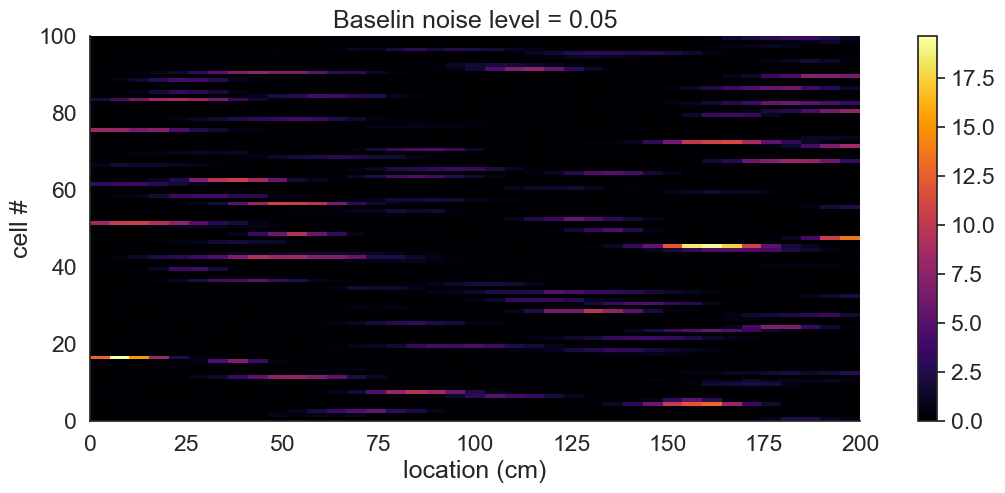

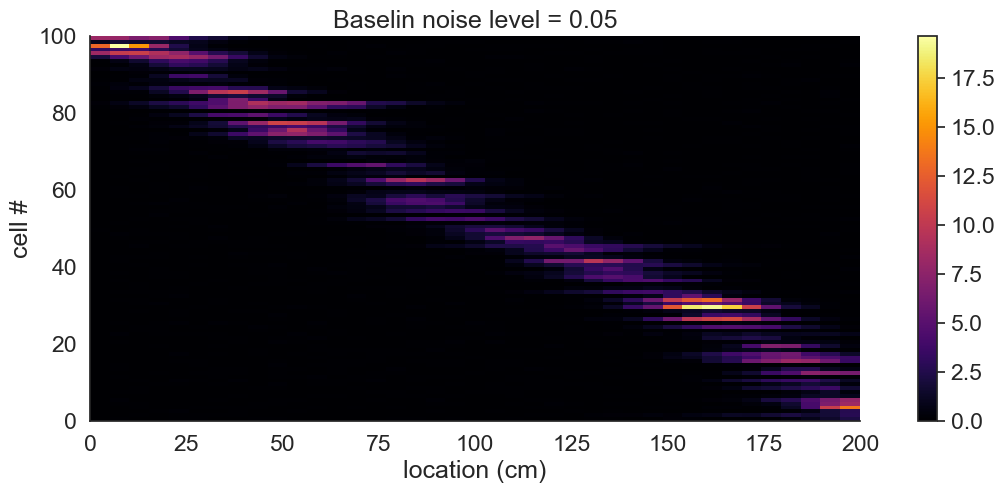

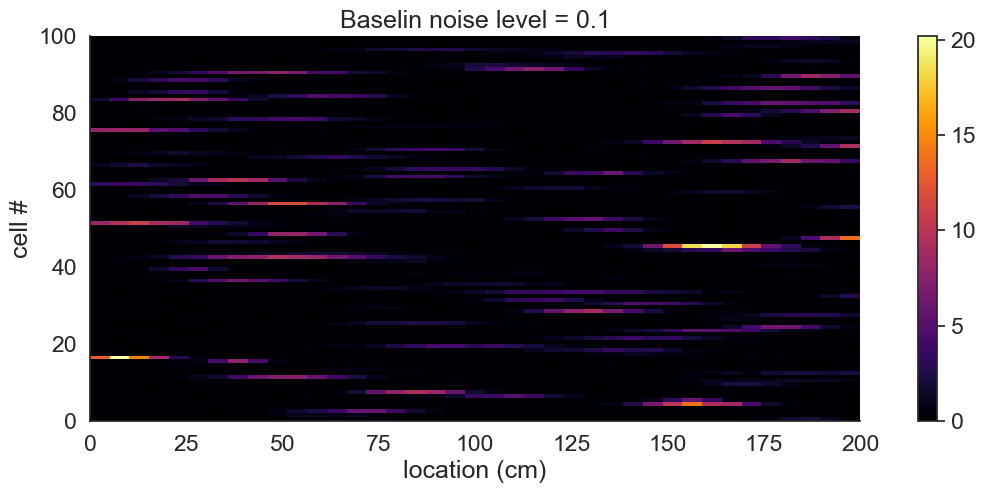

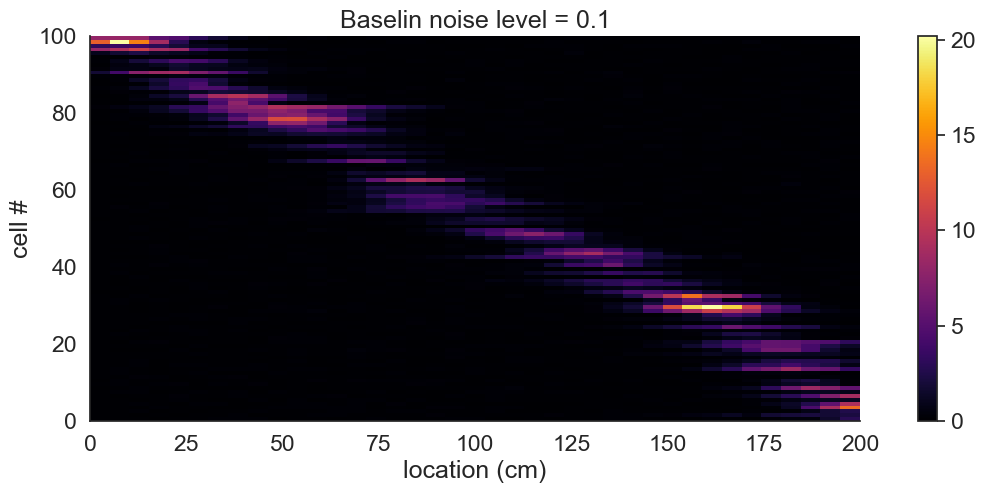

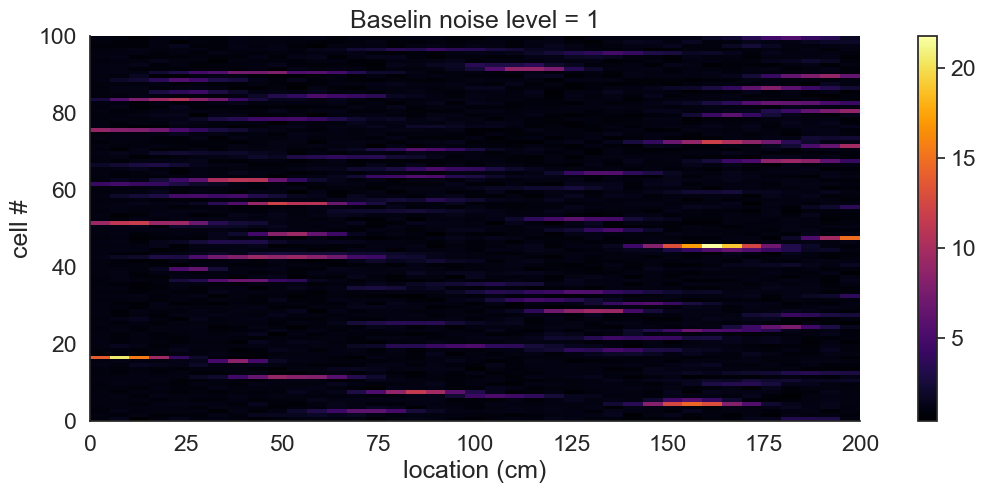

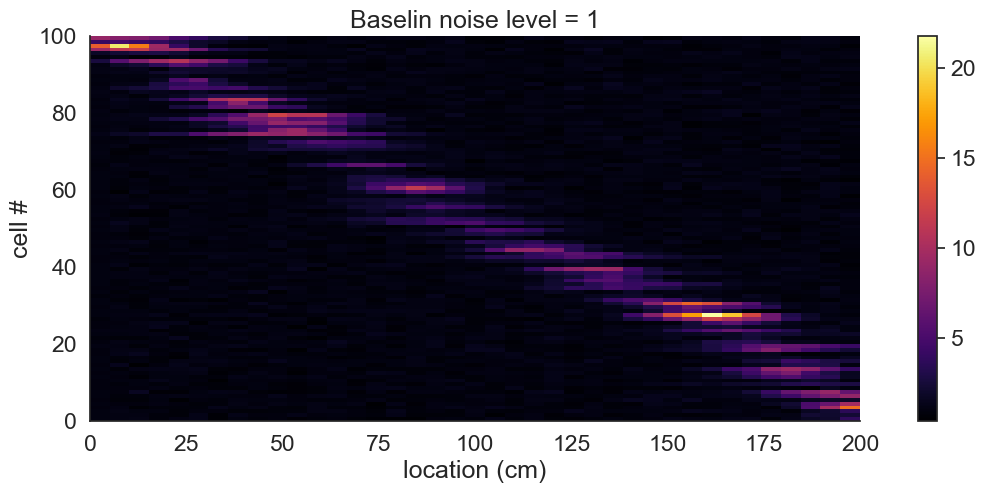

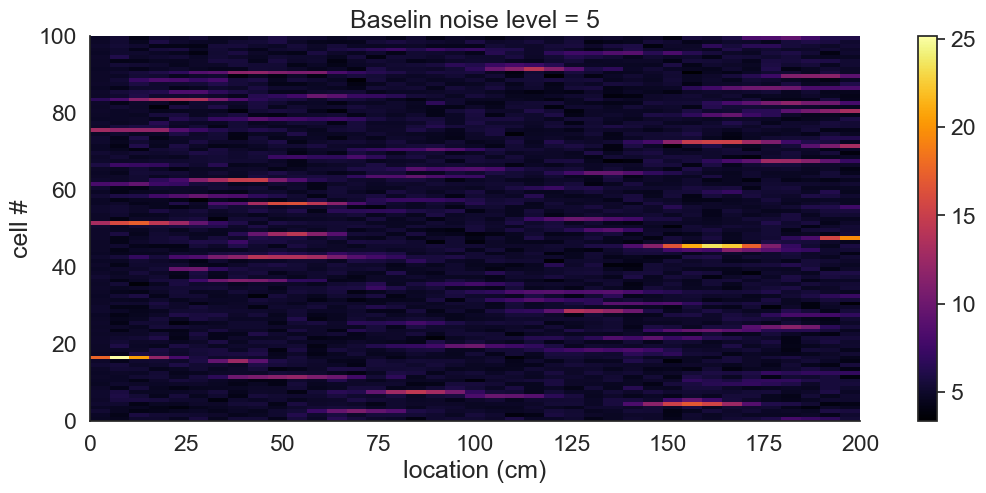

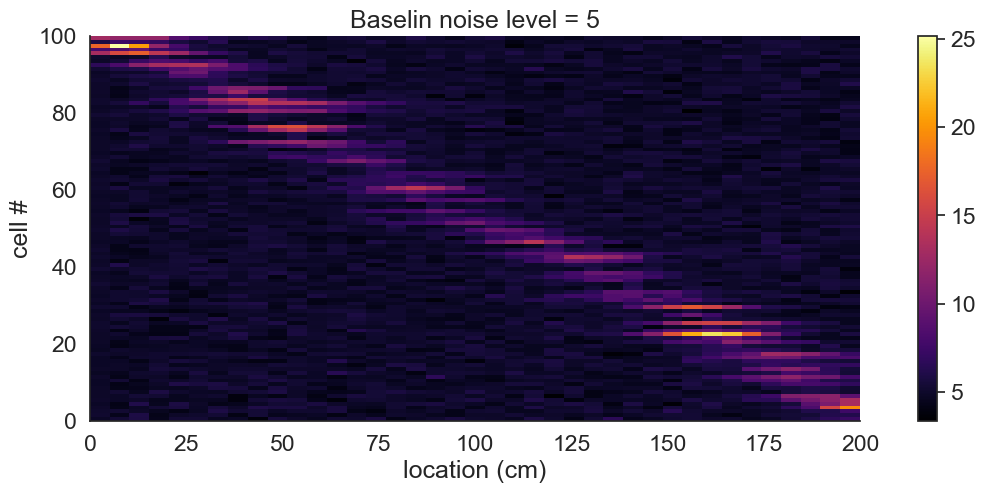

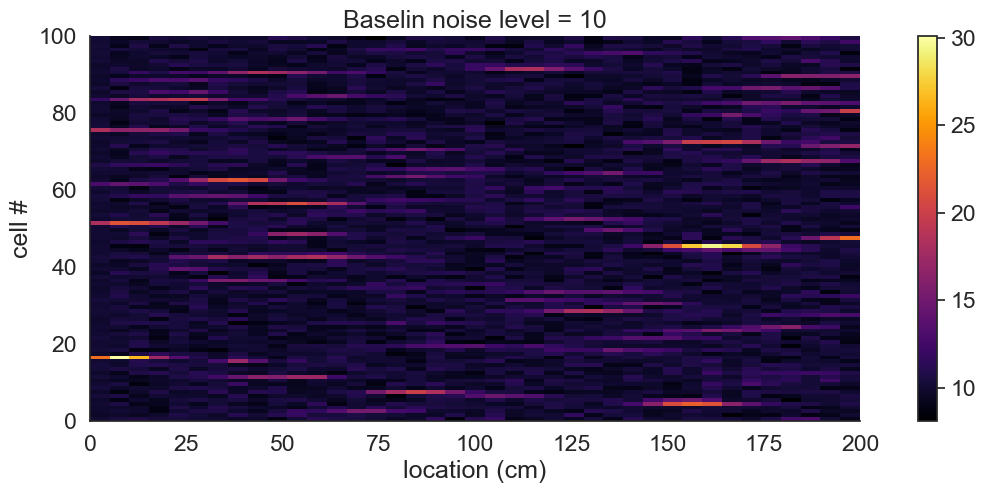

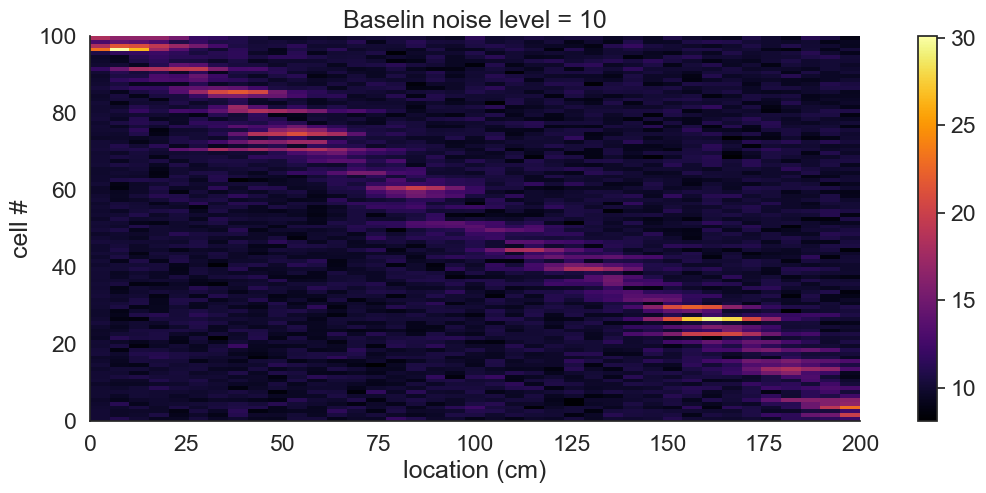

In [ ]:
#Excersize B
noise_levels = [0.05, 0.1, 1, 5, 10]
for noise_firing_rate in noise_levels:
    spikes = []
    for i in tqdm(range(n_cells)):
        inst_rate = true_firing_rate_maps[i,x_sampling.astype(np.int32)] + noise_firing_rate
        spikes_loc = np.random.poisson(inst_rate/sampling_rate)
        sp = np.argwhere(spikes_loc)
        t_sp = t_sampling[sp]
        spikes.append(t_sp)

    spike_positions = [np.interp(s, t, x) for s in spikes]

    space_bins = np.arange(0., 200., 5.)

# we compute histograms for eaxh cell
    spikes_hist= [np.histogram(s, space_bins)[0] for s in spike_positions]

# put them together into a matrix of floating point numbers (for plotting)
    spikes_hist = np.vstack(spikes_hist).astype(np.float64)

# we also need an "occupancy histogram" in order to normalize the firing rates maps 
    occupancy = np.histogram(x, space_bins)[0] /  fps

    firing_rate_maps = spikes_hist / occupancy 

    plt.figure(figsize=(15,5))
    plt.imshow(firing_rate_maps, cmap='inferno', extent = [0, 200, 0, n_cells])
    plt.xlabel('location (cm)')
    plt.ylabel('cell #')
    plt.colorbar()
    plt.title(f"Baselin noise level = {noise_firing_rate}")

    plt.figure(figsize=(15,5))
    peak_locations = firing_rate_maps.argmax(axis=1)
    ix = np.argsort(peak_locations)
    plt.imshow(firing_rate_maps[ix,:], cmap='inferno', extent = [0, 200, 0, n_cells])
    plt.xlabel('location (cm)')
    plt.ylabel('cell #')
    plt.colorbar()
    plt.title(f"Baselin noise level = {noise_firing_rate}")

# As you can see, the higher baseline noise, the more noise that is place independent
# and the place fields become less visible compared to the background

100%|██████████| 100/100 [00:39<00:00,  2.51it/s]


Text(0.5, 1.0, 'High baseline noise with broader space bins')

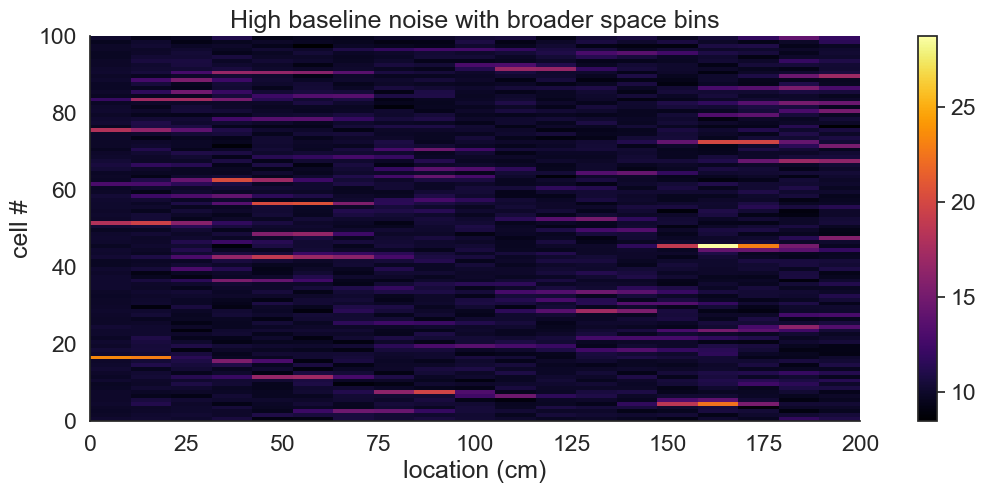

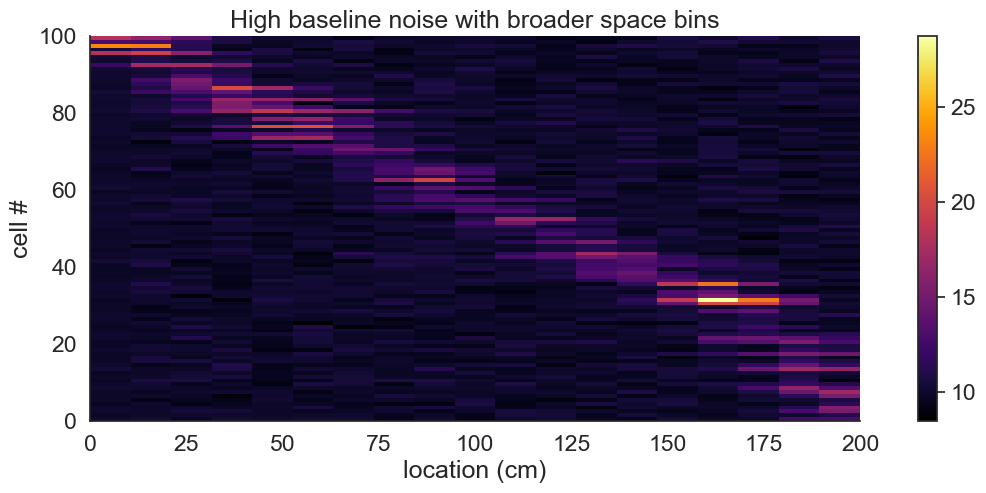

In [ ]:
# B part 2

noise_firing_rate = 10 # the baseline noise firing rate
spikes = []

for i in tqdm(range(n_cells)):
    inst_rate = true_firing_rate_maps[i,x_sampling.astype(np.int32)] + noise_firing_rate
    spikes_loc = np.random.poisson(inst_rate/sampling_rate)
    sp = np.argwhere(spikes_loc)
    t_sp = t_sampling[sp]
    spikes.append(t_sp)

spike_positions = [np.interp(s, t, x) for s in spikes]

space_bins = np.arange(0., 200., 10.) # increased the space bin broadness

# we compute histograms for eaxh cell
spikes_hist= [np.histogram(s, space_bins)[0] for s in spike_positions]

# put them together into a matrix of floating point numbers (for plotting)
spikes_hist = np.vstack(spikes_hist).astype(np.float64)

# we also need an "occupancy histogram" in order to normalize the firing rates maps 
occupancy = np.histogram(x, space_bins)[0] /  fps

firing_rate_maps = spikes_hist / occupancy 

plt.figure(figsize=(15,5))
plt.imshow(firing_rate_maps, cmap='inferno', extent = [0, 200, 0, n_cells])
plt.xlabel('location (cm)')
plt.ylabel('cell #')
plt.colorbar()
plt.title("High baseline noise with broader space bins")

plt.figure(figsize=(15,5))
peak_locations = firing_rate_maps.argmax(axis=1)
ix = np.argsort(peak_locations)
plt.imshow(firing_rate_maps[ix,:], cmap='inferno', extent = [0, 200, 0, n_cells])
plt.xlabel('location (cm)')
plt.ylabel('cell #')
plt.colorbar()
plt.title("High baseline noise with broader space bins")

# With broader spatial bins the background looks less noisy that with the 
# smaller spatial bins (last figure above has 5 and this one 10), So increasing the
# broadness of spatial bins the firing rate maps become more visuably clear

100%|██████████| 100/100 [02:26<00:00,  1.47s/it]


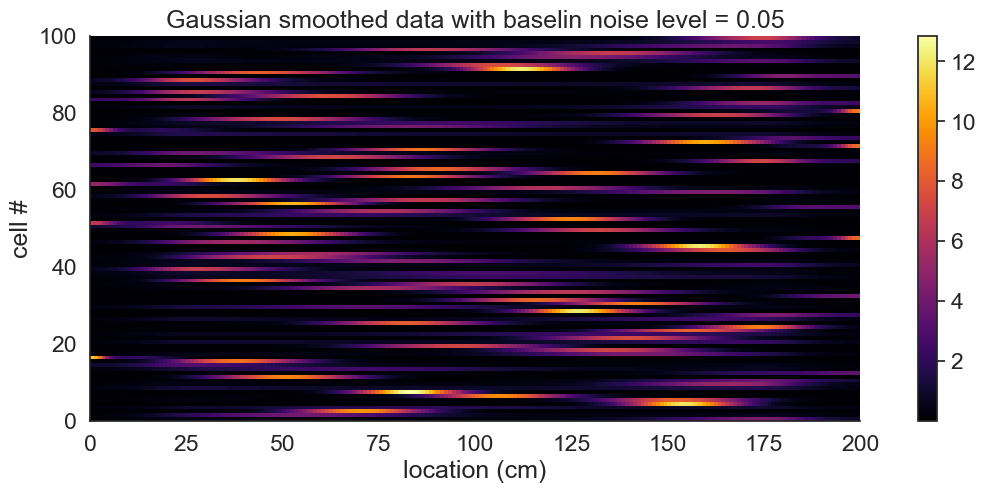

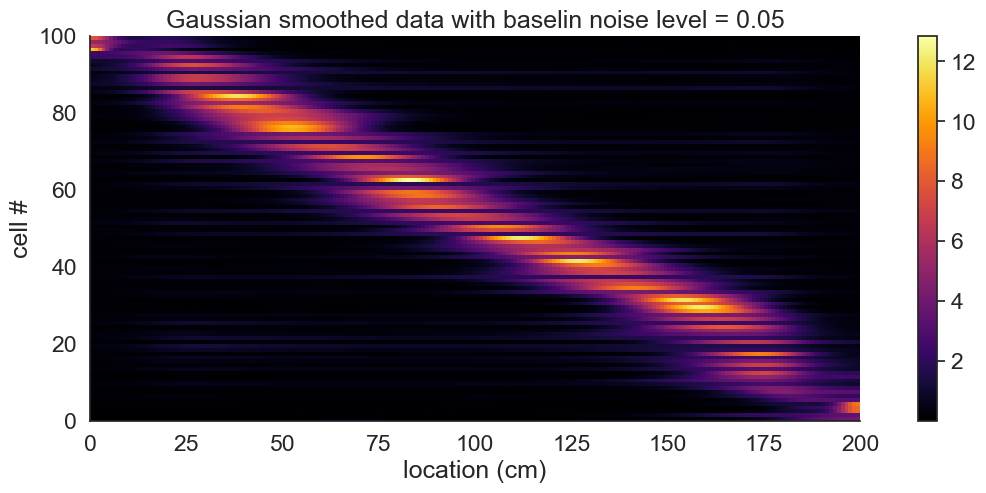

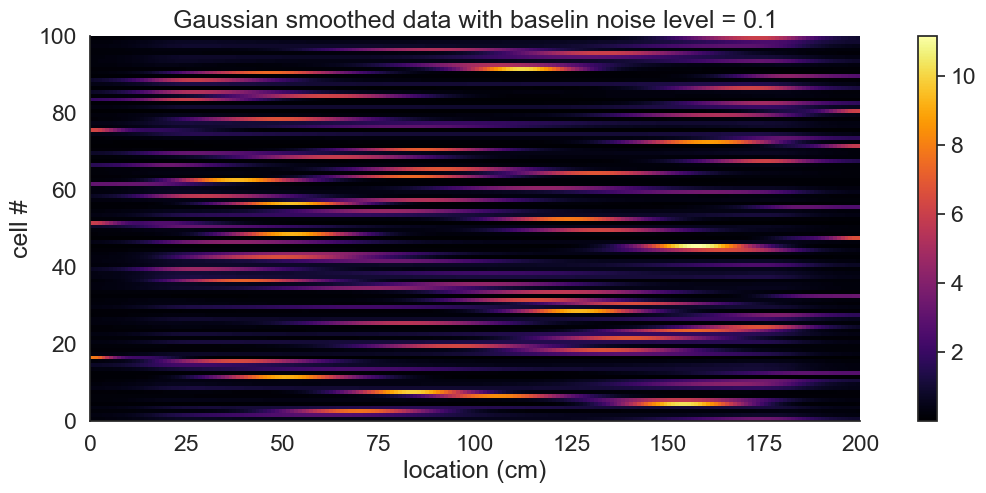

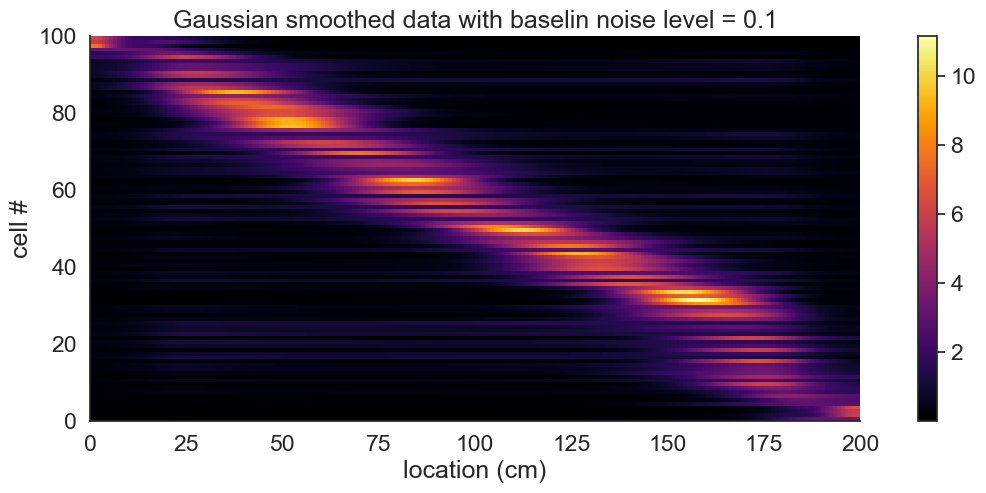

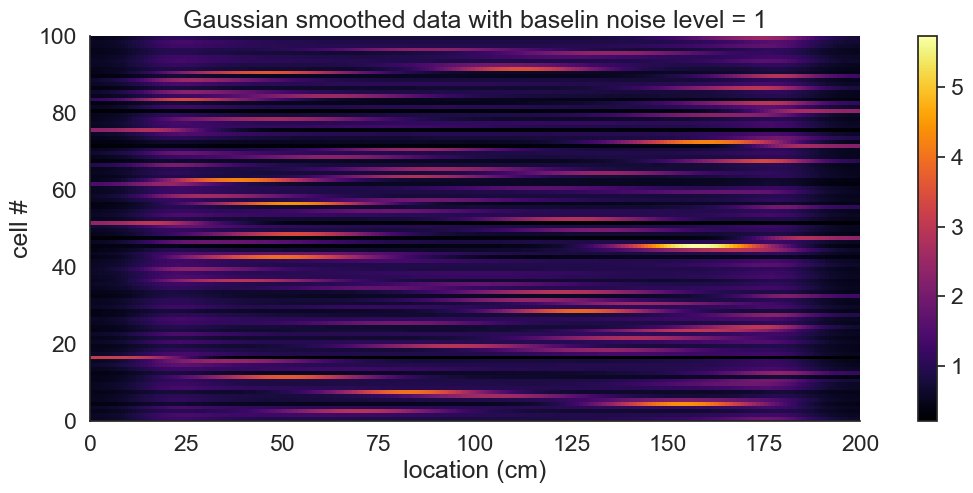

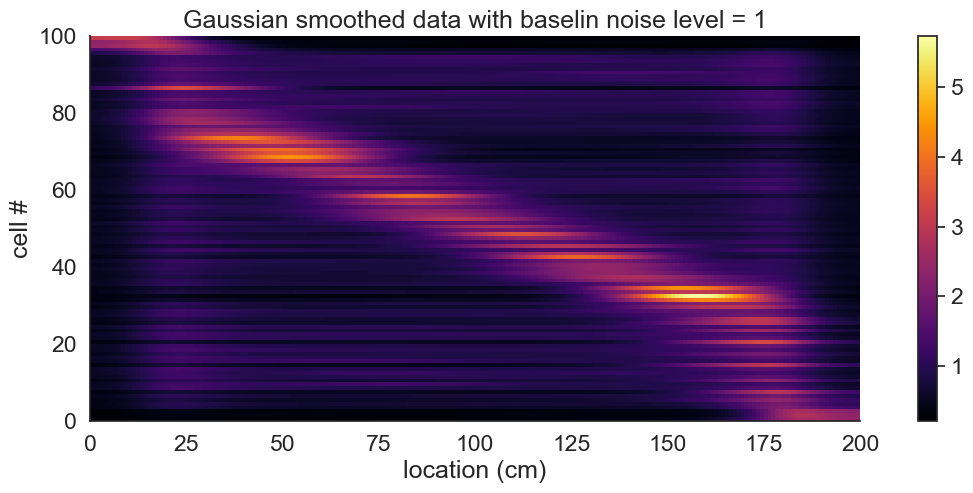

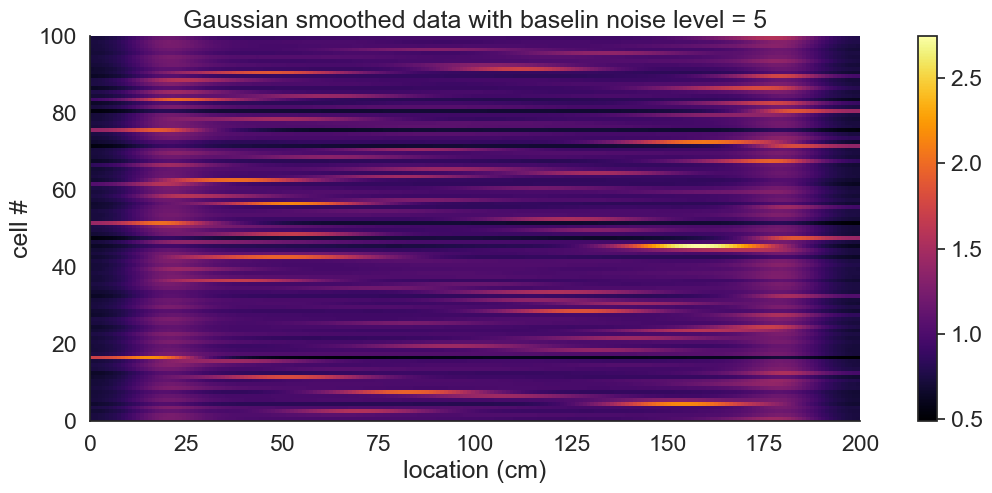

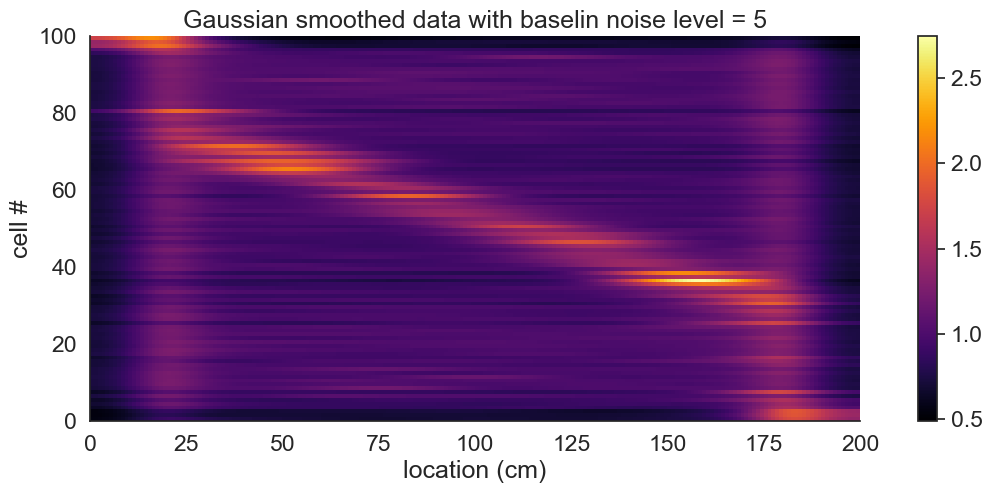

In [ ]:
noise_levels = [0.05, 0.1, 1, 5]
space_bins = np.arange(0, 200 , 1.)
occupancy_kde = gaussian_kde(x)
occupancy_values = occupancy_kde(space_bins) # Apply KDE to the animal's positions to estimate the smoothed occupancy
                                             # distribution. This is used later to correct for how much time the animal
                                             # spent at each location.
for noise_firing_rate in noise_levels:
    spikes = []
    for i in tqdm(range(n_cells)):
        inst_rate = true_firing_rate_maps[i,x_sampling.astype(np.int32)] + noise_firing_rate
        spikes_loc = np.random.poisson(inst_rate/sampling_rate)
        sp = np.argwhere(spikes_loc)
        t_sp = t_sampling[sp]
        spikes.append(t_sp)

    spike_positions = [np.interp(s, t, x) for s in spikes]
    kde_list = []
    for s in spike_positions: # Apply the KDE gaussian smoother to the data of positions of spikes
        data = s.flatten()
        kde_list.append(gaussian_kde(data))

        

    values = []
    for kde in kde_list:
            values.append(kde(space_bins)) # Select the smoothed data within a certain position
    values = np.vstack(values)
    final_values = values/occupancy_values # Adjust for occupancy time

    # Plot the normal and the sorted firing rate maps
    plt.figure(figsize=(15,5))
    plt.imshow(final_values, cmap='inferno', extent = [0, 200, 0, n_cells])
    plt.xlabel('location (cm)')
    plt.ylabel('cell #')
    plt.colorbar()
    plt.title(f"Gaussian smoothed data with baselin noise level = {noise_firing_rate}")

    plt.figure(figsize=(15,5))
    peak_locations = final_values.argmax(axis=1)
    ix = np.argsort(peak_locations)
    plt.imshow(final_values[ix,:], cmap='inferno', extent = [0, 200, 0, n_cells])
    plt.xlabel('location (cm)')
    plt.ylabel('cell #')
    plt.colorbar()
    plt.title(f"Gaussian smoothed data with baselin noise level = {noise_firing_rate}")

    # The gaussian KDE smoother makes the firing rate maps smoother and reduces random
    # fluctuations. Again with high baseline noise the place fields become less clear'
    # due to the non location specific noise

[117.22403755 178.2563293  125.21650087 118.19936486  10.25195707
  15.08041659  82.14198446 150.91524958 144.61254405  77.4868376
 147.4074541   90.24623998  83.84020027  98.68483891  23.26348087
 164.72772801 123.47368931 107.76268418 150.25048071 130.16271832
 150.77516534  91.00711753  89.06926019 145.30807803  73.624547
  79.65463921 109.90836785 111.71354664  55.66616428  88.7488242
 153.195598    95.89345785  78.64259255 173.32677219 133.72190132
 101.87321292 109.90666187  39.50533209  98.67446672  68.16583724
  50.92079709  31.58021179  33.95650041 131.59788192 143.63254228
  65.03265906  33.36231822  59.93546862 106.93237726  41.00219736
 118.67727061 120.21701035 134.58323236  72.3724475   60.55277067
  82.26946642 180.02393332 112.72388036 118.05755687 146.47770105
 109.6004868   28.62172343 125.35391434 152.62793576 183.6497911
  60.29003729 122.66541233  87.65637023  72.74431091 135.91315007
 126.69721618 105.22250011 111.86152326 156.76820575  90.67737183
  55.13004659  

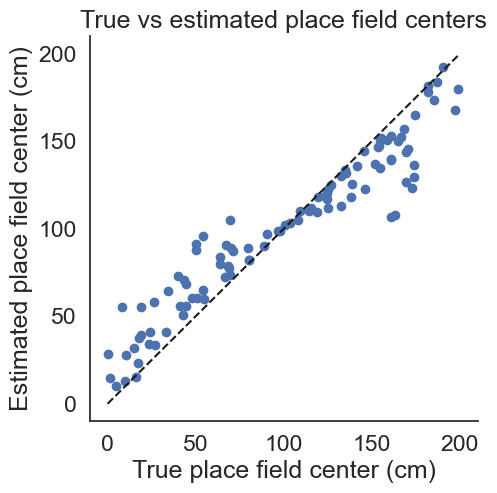

In [ ]:
#D
# Ran the simulation again in the code in cell 3 before running the code in the current cell
center = []

# Centers of masses calculated with the formule
for s in spike_positions:
    data = s.flatten()
    center.append(np.mean(data))

center = np.array(center)

print(center)

# Calculated center of mass plotted against the simulated center of mass
plt.figure(figsize=(5,5))
plt.scatter(pf_centers, center)
plt.plot([0, 200], [0, 200], 'k--')
plt.xlabel("True place field center (cm)")
plt.ylabel("Estimated place field center (cm)")
plt.title("True vs estimated place field centers")
plt.show()

## Exercise 2 - mutual information
---
A - Implement the mutual information formula discussed in the lesson, and apply it to the place cell data we simulated.

B - Adapt the simulation so that you can systematically vary 1) Peak firing rate, 2) place cell size 3) baseline noise. 
Study how mutual information vary with these parameters. Use both definition of mutual information above, and discuss the differences between them. Make some plots to show how the dependency goes.

In [55]:
# Simulate the data again. All copied from the tuning-curves.ipynb file
track_length = 200. # the length of our linear track (eg in centimeter)
average_firing_rate = 5 # the peak firing rate, averaged across the population 
n_cells = 100 # how many cells we are recording
pf_centers = np.random.rand(n_cells) * track_length # the centers of the place fields for all cells drawn randomly with a uniform distribution on the track
pf_size = np.random.gamma(10, size=n_cells) # the size (width) of the place fields, drawn randomly from a gamma distribution 
pf_rate = np.random.exponential(scale=average_firing_rate, size=n_cells)

bins = np.arange(0., 200.)
true_firing_rate_maps = np.zeros((n_cells, len(bins)))
for i in range(n_cells):
    true_firing_rate_maps[i,:] = pf_rate[i] * np.exp(-((bins-pf_centers[i])**2)/(2*pf_size[i]**2))

n_runs = 20 
av_running_speed = 10 # the average running speed (in cm/s)
fps = 30 # the number of "video frames" per second 
running_speed_a = np.random.chisquare(10, size=n_runs) # running speed in the two directions
running_speed_b = np.random.chisquare(10, size=n_runs) 

stopping_time_a = np.random.chisquare(15, size=n_runs) # the time the mouse will spend at the two ends of the track
stopping_time_b = np.random.chisquare(15, size=n_runs)

x = np.array([])
for i in range(n_runs):
    stop1 = np.ones((int(stopping_time_a[i]*fps),)) * 0.
    run_length = len(bins) * fps / running_speed_a[i]
    run1 = np.linspace(0., float(len(bins)-1), int(run_length))
    stop2 = np.ones((int(stopping_time_b[i]*fps),)) * (len(bins)-1.)
    run_length = len(bins) * fps / running_speed_b[i]
    run2 = np.linspace(len(bins)-1., 0., int(run_length))
    x = np.concatenate((x, stop1, run1, stop2, run2))
t = np.arange(len(x))/fps

sampling_rate = 10000.
t_sampling = np.arange(0, t[-1], 1. / sampling_rate)
x_sampling = np.floor(np.interp(t_sampling, t, x))
noise_firing_rate = 0.1 # the baseline noise firing rate
spikes = []

for i in tqdm(range(n_cells)):
    inst_rate = true_firing_rate_maps[i,x_sampling.astype(np.int32)] + noise_firing_rate
    spikes_loc = np.random.poisson(inst_rate/sampling_rate)
    sp = np.argwhere(spikes_loc)
    t_sp = t_sampling[sp]
    spikes.append(t_sp)

spike_positions = [np.interp(s, t, x) for s in spikes]

space_bins = np.arange(0., 200., 5.)

# we compute histograms for eaxh cell
spikes_hist= [np.histogram(s, space_bins)[0] for s in spike_positions]

# put them together into a matrix of floating point numbers (for plotting)
spikes_hist = np.vstack(spikes_hist).astype(np.float64)

# we also need an "occupancy histogram" in order to normalize the firing rates maps 
occupancy = np.histogram(x, space_bins)[0] /  fps

firing_rate_maps = spikes_hist / occupancy 

100%|██████████| 100/100 [00:43<00:00,  2.30it/s]


Text(0.5, 1.0, 'Spatial information per cell')

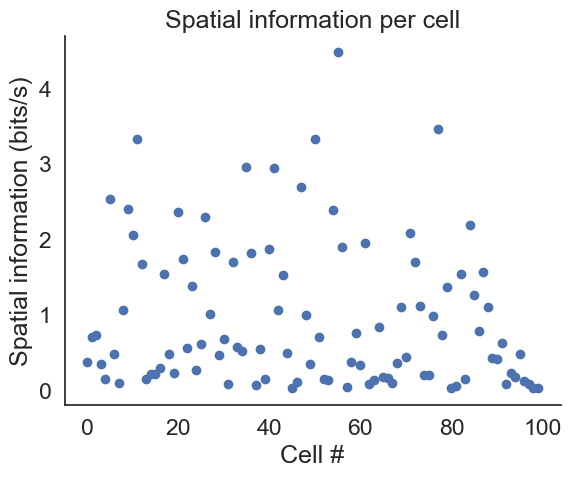

In [ ]:
#2A
occupancy_prob = occupancy/np.sum(occupancy) # make list with the probability of occupancy per position
info = []
epsilon = 1e-15

for current_cell in firing_rate_maps:
    labda = np.sum(current_cell*occupancy_prob) # mean firing rate with  labda = integral over x labda(x)*p(x) dx

    current_info = [] 

    for i in range(len(current_cell)): #for loop where per cell per position the information is calculated
        current_info.append(current_cell[i]*np.log2((current_cell[i] + epsilon)/labda)*occupancy_prob[i])
    
    info.append(np.sum(current_info)) 

plt.scatter(np.arange(len(info)), info) # scatter plot of firing rates per cell
plt.xlabel("Cell #")
plt.ylabel("Spatial information (bits/s)")
plt.title("Spatial information per cell")


In [2]:
#2B
def simulation(peak_fire_rate, cell_size, base_noise):
    # Simulate the data again. All copied from the tuning-curves.ipynb file
    track_length = 200. # the length of our linear track (eg in centimeter)
    average_firing_rate = peak_fire_rate # the peak firing rate, averaged across the population 
    n_cells = 100 # how many cells we are recording
    pf_centers = np.random.rand(n_cells) * track_length # the centers of the place fields for all cells drawn randomly with a uniform distribution on the track
    pf_size = np.random.gamma(10, size=n_cells) * cell_size# the size (width) of the place fields, drawn randomly from a gamma distribution 
    pf_rate = np.random.exponential(scale=average_firing_rate, size=n_cells)

    bins = np.arange(0., 200.)
    true_firing_rate_maps = np.zeros((n_cells, len(bins)))
    for i in range(n_cells):
        true_firing_rate_maps[i,:] = pf_rate[i] * np.exp(-((bins-pf_centers[i])**2)/(2*pf_size[i]**2))

    n_runs = 20 
    av_running_speed = 10 # the average running speed (in cm/s)
    fps = 30 # the number of "video frames" per second 
    running_speed_a = np.random.chisquare(10, size=n_runs) # running speed in the two directions
    running_speed_b = np.random.chisquare(10, size=n_runs) 

    stopping_time_a = np.random.chisquare(15, size=n_runs) # the time the mouse will spend at the two ends of the track
    stopping_time_b = np.random.chisquare(15, size=n_runs)

    x = np.array([])
    for i in range(n_runs):
        stop1 = np.ones((int(stopping_time_a[i]*fps),)) * 0.
        run_length = len(bins) * fps / running_speed_a[i]
        run1 = np.linspace(0., float(len(bins)-1), int(run_length))
        stop2 = np.ones((int(stopping_time_b[i]*fps),)) * (len(bins)-1.)
        run_length = len(bins) * fps / running_speed_b[i]
        run2 = np.linspace(len(bins)-1., 0., int(run_length))
        x = np.concatenate((x, stop1, run1, stop2, run2))
    t = np.arange(len(x))/fps

    sampling_rate = 10000.
    t_sampling = np.arange(0, t[-1], 1. / sampling_rate)
    x_sampling = np.floor(np.interp(t_sampling, t, x))
    noise_firing_rate = base_noise # the baseline noise firing rate
    spikes = []

    for i in tqdm(range(n_cells)):
        inst_rate = true_firing_rate_maps[i,x_sampling.astype(np.int32)] + noise_firing_rate
        spikes_loc = np.random.poisson(inst_rate/sampling_rate)
        sp = np.argwhere(spikes_loc)
        t_sp = t_sampling[sp]
        spikes.append(t_sp)

    spike_positions = [np.interp(s, t, x) for s in spikes]

    space_bins = np.arange(0., 200., 5.)

# we compute histograms for eaxh cell
    spikes_hist= [np.histogram(s, space_bins)[0] for s in spike_positions]

# put them together into a matrix of floating point numbers (for plotting)
    spikes_hist = np.vstack(spikes_hist).astype(np.float64)

# we also need an "occupancy histogram" in order to normalize the firing rates maps 
    occupancy = np.histogram(x, space_bins)[0] /  fps

    firing_rate_maps = spikes_hist / occupancy 

    return(occupancy, firing_rate_maps)

In [3]:
#alter the peak firing rate
fire_rate = [1, 5, 10]
cell_size = [0.5, 1, 1,5]
base_noise = [0.05, 0.1, 0.2]

for fr in fire_rate:
    simulation(fr, cell_size[1], base_noise[1])

    occupancy_prob = occupancy/np.sum(occupancy) # make list with the probability of occupancy per position
    info = []
    epsilon = 1e-15

    for current_cell in firing_rate_maps:
        labda = np.sum(current_cell*occupancy_prob) # mean firing rate with  labda = integral over x labda(x)*p(x) dx

    current_info = [] 

    for i in range(len(current_cell)): #for loop where per cell per position the information is calculated
        current_info.append(current_cell[i]*np.log2((current_cell[i] + epsilon)/labda)*occupancy_prob[i])
    
    info.append(np.sum(current_info)) 

    plt.scatter(np.arange(len(info)), info) # scatter plot of firing rates per cell
    plt.xlabel("Cell #")
    plt.ylabel("Spatial information (bits/s)")
    plt.title(f"Spatial information per cell with peak fire rate {fr} and cell size {cell_size[1]} and base line noise {base_noise[1]}")

NameError: name 'np' is not defined

## Exercise 3 - working with real data
---
Load the data from `linear_track_data.pickle`. It contains neural recordings from a mouse running on a linear track.
- `x` contains the position of the animal
- `t` contains the corresponding times, in seconds
- `spikes` contains a list of lists. Each list contains the timestamps of the spikes emitted by a neuron.

A - Visualiaze the position a s a function of time. Plot the spike of a selected cell in space.

B - Calculate the firing rate maps for all the cells, and plot them sorted by increasing peak positon.

C - Calculate the spatial information for each cell, and plot the distribution. Plot the firing rate maps of the 5 cells with lower spatial information, and the firing rate maps of the 5 cells with higher spatial information. Comment on the differences.